In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

import json

In [3]:
file_path = "2025-07-13_1219_alle_Modelle_cases_v1.json"


# Datei öffnen und laden
with open(file_path, 'r') as f:
    results = json.load(f)

# Alles außer body entfernen
results = results['body']

# Leere Listen anlegen
provider = []
scores = []

# Dateiinhalt durchiterieren
for i in range(0,len(results)):
    for l in range(0,len(results[i]['outputs'])):
        provider.append(results[i]['outputs'][l]['provider']) # Schreibe jeden Provider in eine Liste
        scores.append(results[i]['outputs'][l]['score']) # Schreibe jeden Score in eine Liste

provider_scores_df = pd.DataFrame(data={"Provider": provider, "scores": scores})

provider_set = set(provider) # Set mit allen Providern
provider_list = list(provider_set)

result_df = pd.DataFrame(columns=['Provider', 'Result'])

for provider in range(0, len(provider_list)):
    mean = np.mean(provider_scores_df[provider_scores_df["Provider"]==provider_list[provider]]["scores"])
    #print(f'{provider_list[provider]}: {mean}')
    result_df.loc[provider] = [provider_list[provider], mean]

print(result_df.sort_values(by="Result", ascending=False))

                        Provider    Result
1   file://retrieve_gemma3_4b.py  0.888889
3  file://retrieve_mistral_7b.py  0.857143
4     file://retrieve_mixtral.py  0.634921
2        file://retrieve_phi4.py  0.600000
0    file://retrieve_llama3_3.py  0.441270


In [6]:
def createBoxplot(daten_boxplot, labels, titles, ueberschrift):
    # Grundlegenden Aufbau definieren und zwei Variablen zuweisen
    figure, ax = plt.subplots(nrows=1, ncols=len(daten_boxplot), figsize=(40, 14))
    for i, (daten, label, title) in enumerate(zip(daten_boxplot, labels, titles)):
        # Titel setzen
        ax[i].set_title(title)
        # Skalierung fixieren
        ax[i].set_ylim(0, 1.00)
        # Linien im Hintergrund in hellgrau setzen
        ax[i].yaxis.grid(True, linestyle="-", color="lightgrey")
        # Horizontale, hellere Linien im Abstand von 0,05 ergänzen
        ax[i].set_yticks(np.arange(0, 1.00, 0.05), minor=True)
        ax[i].grid(which='minor', alpha=0.2)
        # Boxplot die Daten und Labels zuweisen
        ax[i].boxplot(daten,
                      tick_labels=label,
                      showmeans=True,
                      meanline=True,
                      meanprops=dict(color='lightseagreen'),
                      medianprops=dict(color='lightseagreen'),
                      notch=False)

    # Schriftart auf "normal" sowie die Schriftgröße auf 14 setzen
    font = {'weight': 'normal',
            'size': 14}
    plt.rc('font', **font)
    # Boxplot ausgeben
    plt.show()
    # Diagramm für als SVG-Datei unter Analysis abspeichern
    figure.savefig(f'boxplot_{ueberschrift}.svg', format="svg")

provider_list.sort()

score_list =[provider_scores_df[provider_scores_df["Provider"]==provider_list[0]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[1]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[2]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[3]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[4]]["scores"]
]

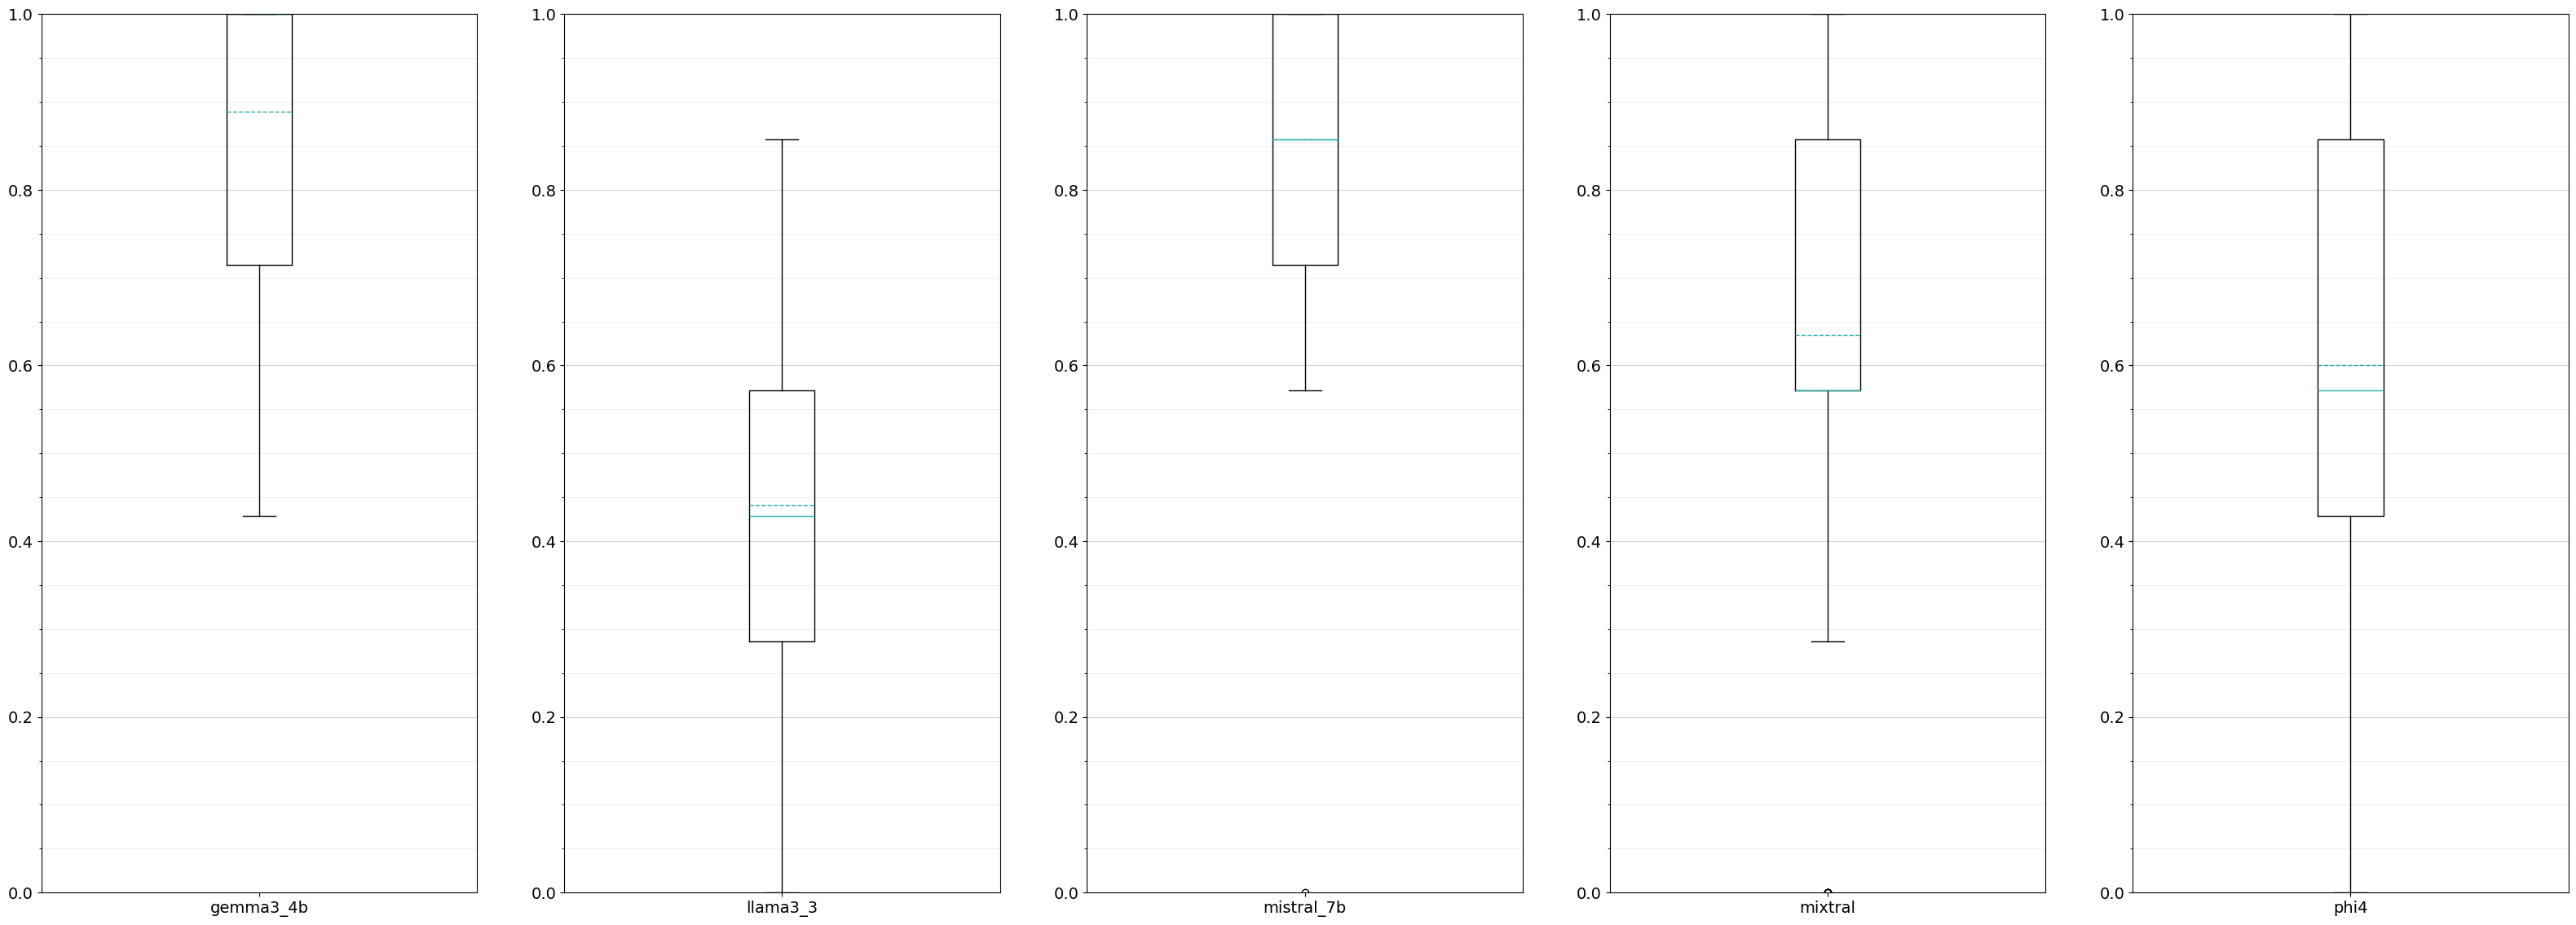

In [8]:
createBoxplot([[score_list[0]], 
               [score_list[1]],
               [score_list[2]],
               [score_list[3]],
               [score_list[4]]],
               [[provider_list[0][16:-3]],
               [provider_list[1][16:-3]],
               [provider_list[2][16:-3]],
               [provider_list[3][16:-3]],
               [provider_list[4][16:-3]]],               
               ["", "", "", "", ""],
               "Ergebnisse")